In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/orbyx-ml-challenge-star-system-classification/sample_submission.csv
/kaggle/input/orbyx-ml-challenge-star-system-classification/train.csv
/kaggle/input/orbyx-ml-challenge-star-system-classification/test.csv


In [26]:
import xgboost as xgb
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
import pandas as pd

In [27]:
df1=pd.read_csv('/kaggle/input/orbyx-ml-challenge-star-system-classification/train.csv')
print(df1)
df1.info()

      star_size  star_brightness  galaxy_region  distance_from_earth  \
0      1.803381         4.217862            0.0            57.986415   
1      0.820914         1.124089            0.0            96.923329   
2      0.745982         0.884981            1.0             5.000000   
3      0.274449         0.381716            1.0           175.711687   
4      0.943031         7.491241            2.0            64.658718   
...         ...              ...            ...                  ...   
6450   1.434594         1.025439            1.0            63.942492   
6451   1.505925         1.578520            1.0            34.109506   
6452   2.117016         2.254183            1.0            12.874281   
6453   1.447891         1.489474            1.0            60.649748   
6454   0.503435         0.945974            0.0            65.209838   

      galaxy_type star_spectral_class planet_configuration  \
0               0                   B  Gas_Giant_Dominated   
1          

In [28]:
X=df1.iloc[:,:-1]
y=df1.iloc[:,-1]


In [29]:
import numpy as np

d = X['distance_from_earth'].values
m = X['star_brightness'].values

# Avoid log10(0) or negative distance
d = np.clip(d, 1.0, None)  # safety

M = m - 5 * np.log10(d) + 5
L = 10 ** ((4.74 - M) / 2.5)

X['log_luminosity'] = np.log10(L)

# Optional: cap extreme outliers (rare)
X['log_luminosity'] = X['log_luminosity'].clip(-2, 5)

/tmp/ipykernel_49/3069147540.py:9: RuntimeWarning: invalid value encountered in log10
  M = m - 5 * np.log10(d) + 5
/tmp/ipykernel_49/3069147540.py:12: RuntimeWarning: invalid value encountered in log10
  X['log_luminosity'] = np.log10(L)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


In [30]:

# Also create effective temperature approximation (very useful!)
temp_map = {'O': 35000, 'B': 20000, 'A': 8500, 'F': 6500, 'G': 5500, 'K': 4500, 'M': 3000}
X['effective_temp'] = X['star_spectral_class'].map(temp_map)
X['mass_metallicity'] = X['star_mass'] * X['metallicity']
X['mass_temp'] = X['star_mass'] * X['effective_temp']
X['luminosity_metallicity'] = X['log_luminosity'] * X['metallicity']
X['activity_mass'] = (X['stellar_activity_class'].map({'Low':0,'Medium':1,'High':2}) 
                       * X['star_mass'])

# Planet configuration + mass (very strong signal)
X['config_mass'] = X['planet_configuration'] + "_" + pd.cut(X['star_mass'], bins=4, labels=['low','med','high','vhigh']).astype(str)


In [31]:
from sklearn.preprocessing import OneHotEncoder   
from sklearn.pipeline import FeatureUnion   
from sklearn_pandas import DataFrameMapper
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [32]:
nulls_per_column = X.isnull().sum()
print(nulls_per_column)


categorical_feature_mask = X.dtypes == object


categorical_columns = X.columns[categorical_feature_mask].tolist()


non_categorical_columns = X.columns[~categorical_feature_mask].tolist()

numeric_imputation_mapper = DataFrameMapper(
                                            [([numeric_feature], SimpleImputer(strategy="median")) for numeric_feature in non_categorical_columns],
                                            input_df=True,
                                            df_out=True
                                           )

categorical_imputation_mapper = DataFrameMapper(
                                                [([category_feature], SimpleImputer(strategy='most_frequent')) for category_feature in categorical_columns],
                                                input_df=True,
                                                df_out=True
                                               )


star_size                   0
star_brightness           194
galaxy_region              65
distance_from_earth        71
galaxy_type                 0
star_spectral_class         0
planet_configuration        0
stellar_activity_class      0
star_mass                   0
metallicity                 0
log_luminosity            263
effective_temp              0
mass_metallicity            0
mass_temp                   0
luminosity_metallicity    263
activity_mass               0
config_mass                 0
dtype: int64


In [33]:
numeric_categorical_union = FeatureUnion([
                                          ("num_mapper", numeric_imputation_mapper),
                                          ("cat_mapper", categorical_imputation_mapper)
                                         ])

In [34]:
# Source - https://stackoverflow.com/a
# Posted by mangelfdz
# Retrieved 2025-11-22, License - CC BY-SA 4.0

import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin


class dataframe2dict(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self):
        """Mock method"""
        return self

    def transform(self, df: pd.DataFrame):
        return df.to_dict()






In [35]:
from sklearn.feature_extraction import DictVectorizer

In [36]:
from sklearn.model_selection import cross_val_score

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin

class Dictifier(BaseEstimator, TransformerMixin):
   
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # If X is a pandas DataFrame, use its column names
        if hasattr(X, "columns"):
            return [dict(zip(X.columns, row)) for row in X.to_numpy()]
        
        # Otherwise assume it's array-like with no column names
        return [dict(enumerate(row)) for row in X]

In [38]:
pipeline = Pipeline([
                     ("featureunion", numeric_categorical_union),
                     ("dictifier", Dictifier()),
                     
                     ("vectorizer", DictVectorizer(sort=False)),
                     
                     ("clf", xgb.XGBClassifier()),
                    ])


cross_val_scores = cross_val_score(pipeline, X, y, scoring="roc_auc_ovr", cv=5)
print("5-fold AUC: ", cross_val_scores)

print("5-fold AUC: ", np.mean(cross_val_scores))

5-fold AUC:  [0.97516607 0.97741236 0.97955925 0.97702093 0.97698275]
5-fold AUC:  0.9772282724993502


In [39]:
pipeline.fit(X,y)

Pipeline(steps=[('featureunion',
                 FeatureUnion(transformer_list=[('num_mapper',
                                                 DataFrameMapper(df_out=True,
                                                                 drop_cols=[],
                                                                 features=[(['star_size'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['star_brightness'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['galaxy_region'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['distance_from_earth'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['gal...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

<Axes: >

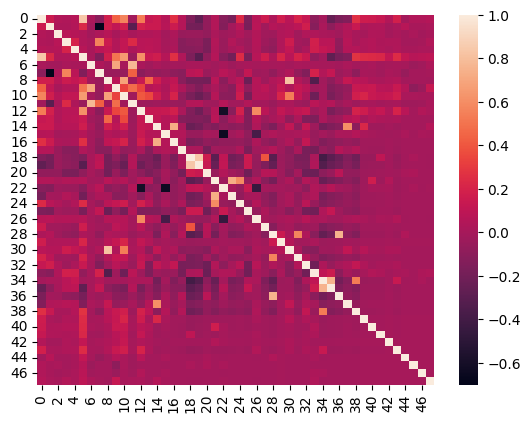

In [40]:
X_dict        = pipeline.named_steps['dictifier'].transform(
                    pipeline.named_steps['featureunion'].transform(X))          
X_transformed = pipeline.named_steps['vectorizer'].transform(X_dict)         
sns.heatmap(pd.DataFrame(X_transformed.toarray()).corr())

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8)

In [42]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('featureunion',
                 FeatureUnion(transformer_list=[('num_mapper',
                                                 DataFrameMapper(df_out=True,
                                                                 drop_cols=[],
                                                                 features=[(['star_size'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['star_brightness'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['galaxy_region'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['distance_from_earth'],
                                                                            SimpleImputer(strategy='median')),
                                                                           (['gal...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [43]:
from sklearn.metrics import accuracy_score
y_prob_val = pipeline.predict_proba(X_test)


best_thr = 0.5
best_acc = 0
for thr in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6]:
    y_pred = pipeline.classes_[np.argmax(y_prob_val >= thr, axis=1)]
    acc = accuracy_score(y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print(f"Best uniform threshold = {best_thr} → Test accuracy = {best_acc:.4f}")

# Final prediction on test set
y_prob_test = pipeline.predict_proba(X_test)
y_pred_final = pipeline.classes_[np.argmax(y_prob_test >= best_thr, axis=1)]

Best uniform threshold = 0.5 → Test accuracy = 0.8869


In [44]:
import pandas as pd
print("Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Train class distribution:
system_type
0    0.307
2    0.250
1    0.243
3    0.200
Name: proportion, dtype: float64

Test class distribution:
system_type
0    0.301
1    0.249
2    0.228
3    0.223
Name: proportion, dtype: float64


In [45]:
from sklearn.metrics import balanced_accuracy_score, f1_score

y_pred = pipeline.predict(X_test)

print(f"Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy_score(y_test, y_pred):.4f}")  
print(f"Macro F1           : {f1_score(y_test, y_pred, average='macro'):.4f}")

Accuracy           : 0.8916
Balanced Accuracy  : 0.8892
Macro F1           : 0.8899


In [46]:
y_pred=pipeline.predict(X_test)

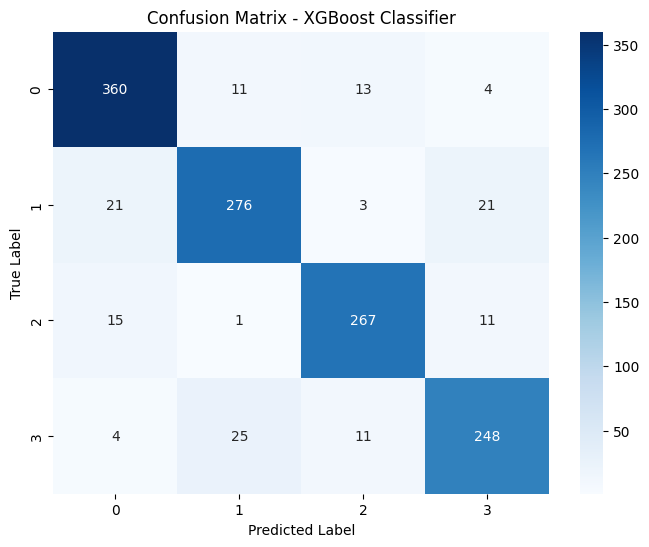

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)
plt.title('Confusion Matrix - XGBoost Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [49]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

In [50]:
accuracy

0.8915569326103796

In [51]:
for metric in ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_ovr']:
    scores = cross_val_score(pipeline, X, y, scoring=metric, cv=5, n_jobs=-1)
    print(f"{metric:15} → {scores.mean():.5f} (+/- {scores.std()*2:.5f})")

accuracy        → 0.87870 (+/- 0.00880)
f1_macro        → 0.87505 (+/- 0.00847)
f1_weighted     → 0.87872 (+/- 0.00899)
roc_auc_ovr     → 0.97723 (+/- 0.00280)


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np
import xgboost as xgb


pipeline = Pipeline([
    ("featureunion", numeric_categorical_union),
    ("dictifier",    Dictifier()),
    ("vectorizer",   DictVectorizer(sort=False)),
    ("clf",          xgb.XGBClassifier(
                        objective='multi:softprob', 
                        eval_metric='mlogloss',
                        random_state=42,
                        n_jobs=-1))
])


param_distributions = {
    
    'clf__n_estimators'     : randint(200, 1200),
    'clf__learning_rate'    : uniform(0.01, 0.29),       
    'clf__max_depth'        : randint(3, 10),
    'clf__min_child_weight' : randint(1, 10),
    'clf__subsample'        : uniform(0.6, 0.4),        
    'clf__colsample_bytree' : uniform(0.6, 0.4),         
    'clf__gamma'            : uniform(0, 10),
    'clf__reg_alpha'        : uniform(0, 1),
    'clf__reg_lambda'       : uniform(0, 3),
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=200,               
    scoring='accuracy',    
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X, y)

print("Best AUC:", random_search.best_score_)
print("Best parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")


best_pipeline = random_search.best_estimator_

X_test = testdf.drop(['id'], axis=1)
preds = best_pipeline.predict(X_test)

submission = pd.DataFrame({
    'id': testdf['id'],
    'system_type': preds
})


In [52]:

feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()

print("Number of features XGBoost saw:", len(feature_names))
print(feature_names)

Number of features XGBoost saw: 48
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13=M'
 '14=Compact_System' '15=Medium' '16=Compact_System_low' '13=K'
 '14=Rocky_Dominated' '16=Rocky_Dominated_low' '13=B' '14=Single_Planet'
 '16=Single_Planet_med' '13=A' '15=High' '16=Compact_System_med'
 '16=Single_Planet_low' '14=Gas_Giant_Dominated' '15=Low'
 '16=Gas_Giant_Dominated_low' '13=F' '14=Mixed_System'
 '16=Mixed_System_low' '16=Rocky_Dominated_med' '13=G' '13=O'
 '16=Gas_Giant_Dominated_med' '16=Mixed_System_med'
 '16=Single_Planet_high' '16=Rocky_Dominated_high' '16=Mixed_System_high'
 '16=Gas_Giant_Dominated_high' '16=Compact_System_high'
 '16=Single_Planet_vhigh' '16=Compact_System_vhigh'
 '16=Rocky_Dominated_vhigh' '16=Gas_Giant_Dominated_vhigh'
 '16=Mixed_System_vhigh']


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

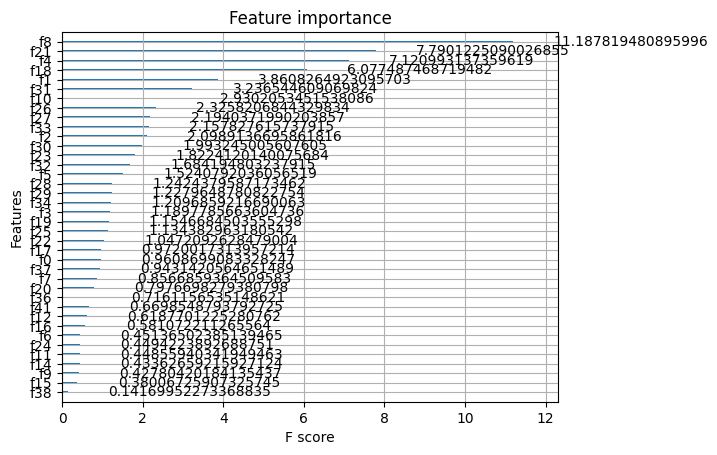

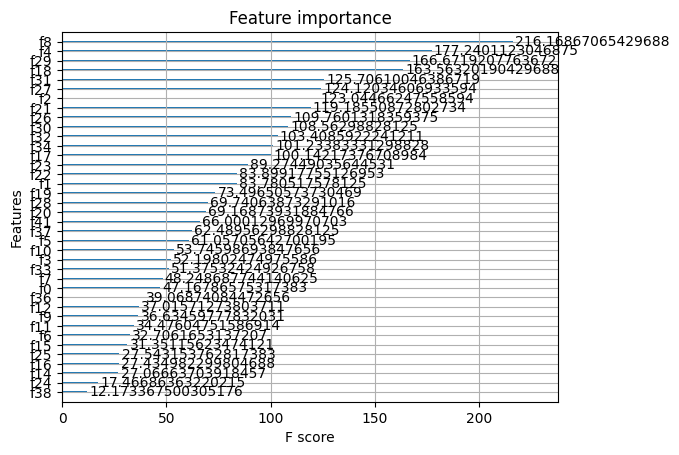

In [53]:
from sklearn.inspection import permutation_importance
import shap

model = pipeline.named_steps['clf']


model.get_booster().get_score(importance_type='gain')     
xgb.plot_importance(model, importance_type='gain')  
xgb.plot_importance(model, importance_type='cover')     


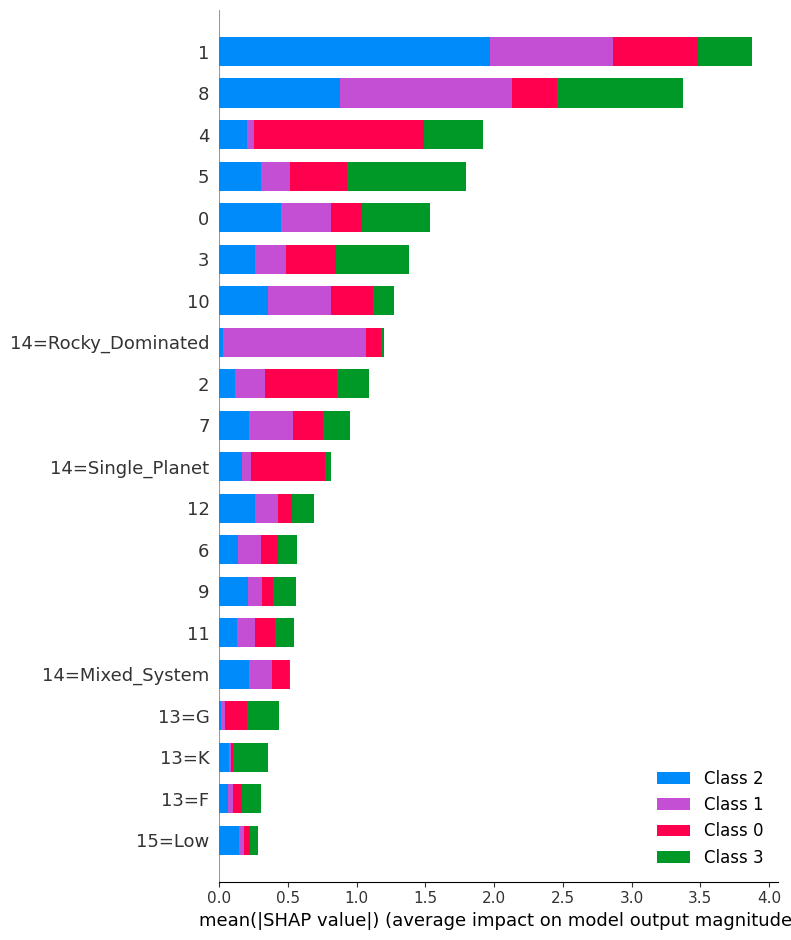

In [54]:

model         = pipeline.named_steps['clf']                                      
feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()      
X_dict        = pipeline.named_steps['dictifier'].transform(
                    pipeline.named_steps['featureunion'].transform(X))          
X_transformed = pipeline.named_steps['vectorizer'].transform(X_dict)            

explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_transformed)   

!
shap.summary_plot(shap_values, X_transformed, 
                  feature_names=feature_names, plot_type="bar")   

               

basic_submission = {'id' : testdf.id, 'system_type': preds}
base_submission = pd.DataFrame(data=basic_submission)
base_submission.to_csv('base_submission.csv', index=False)